Importing & loading data from SQLite

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


conn = sqlite3.connect("credit_risk.db")
df = pd.read_sql("SELECT * from loans", conn)
conn.close()

print(f"Shapes: {df.shape}")
print(f"Default rate: {df["is_default"].mean():.1%}")
df.head()

Shapes: (8429, 145)
Default rate: 17.5%


,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,is_default
0,None,30000,30000,30000.0,36 months,22.35,1151.16,D,D5,Supervisor,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,None,40000,40000,40000.0,60 months,16.14,975.71,C,C4,Assistant to the Treasurer (Payroll),...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,None,20000,20000,20000.0,36 months,7.56,622.68,A,A3,Teacher,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
3,None,4500,4500,4500.0,36 months,11.31,147.99,B,B3,Accounts Examiner III,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,None,8425,8425,8425.0,36 months,27.27,345.18,E,E5,Senior Director Risk Management,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


Checking missing value

In [4]:
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(1)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

print(missing_summary.head(20))

                                            missing_count  missing_pct
member_id                                            8429        100.0
hardship_type                                        8428        100.0
hardship_status                                      8428        100.0
deferral_term                                        8428        100.0
hardship_amount                                      8428        100.0
hardship_start_date                                  8428        100.0
hardship_end_date                                    8428        100.0
payment_plan_start_date                              8428        100.0
hardship_length                                      8428        100.0
hardship_dpd                                         8428        100.0
hardship_loan_status                                 8428        100.0
orig_projected_additional_accrued_interest           8428        100.0
hardship_payoff_balance_amount                       8428        100.0
hardsh

Drop high-missing column and fill in the rest

In [13]:
#Droping col when >50% missing
thershold = 50
cols_to_drop = missing_summary[missing_summary["missing_pct"]>thershold].index.tolist()
df = df.drop(columns=cols_to_drop, errors="ignore")
print(f"dropped {len(cols_to_drop)} Column. Remaining: {df.shape[1]}")

#fill numeric nulls with median
numeric_col = df.select_dtypes(include="number").columns
df[numeric_col] = df[numeric_col].fillna(df[numeric_col].median())

#fill categorical nulls with "unknown"
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Missing value remaining:", df.isnull().sum().sum())

dropped 43 Column. Remaining: 102
Missing value remaining: 0


/var/folders/4s/phwctbwd5r39t7s2tmzqpt380000gn/T/ipykernel_66448/3567106737.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Default rate by loan grade (bar chart)

/var/folders/4s/phwctbwd5r39t7s2tmzqpt380000gn/T/ipykernel_66448/1327590780.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grade_summary, x="grade", y="default_rate_pct", palette="Blues_d")


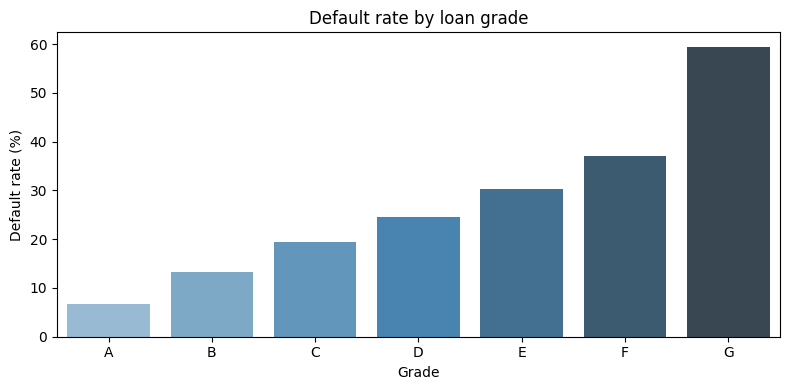

In [14]:
grade_summary = df.groupby("grade")["is_default"].mean().reset_index()
grade_summary["default_rate_pct"]  =grade_summary["is_default"]*100

plt.figure(figsize=(8,4))
sns.barplot(data=grade_summary, x="grade", y="default_rate_pct", palette="Blues_d")
plt.title("Default rate by loan grade")
plt.xlabel("Grade")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.savefig("Chart_grade_default.png", dpi=150)
plt.show()

Loam amount distribution: default Vs Paid

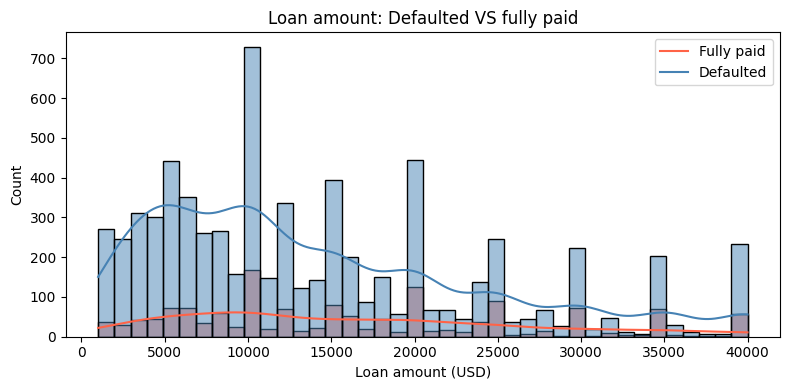

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(
    data=df, x='loan_amnt', hue="is_default", bins=40, kde=True, palette={0: "steelblue", 1:"tomato"}
)

plt.title("Loan amount: Defaulted VS fully paid")
plt.xlabel("Loan amount (USD)")
plt.legend(["Fully paid", "Defaulted"])
plt.tight_layout()
plt.savefig("Chart_loan_amnt_dist.png", dpi=150)
plt.show()


Correlation heatmap

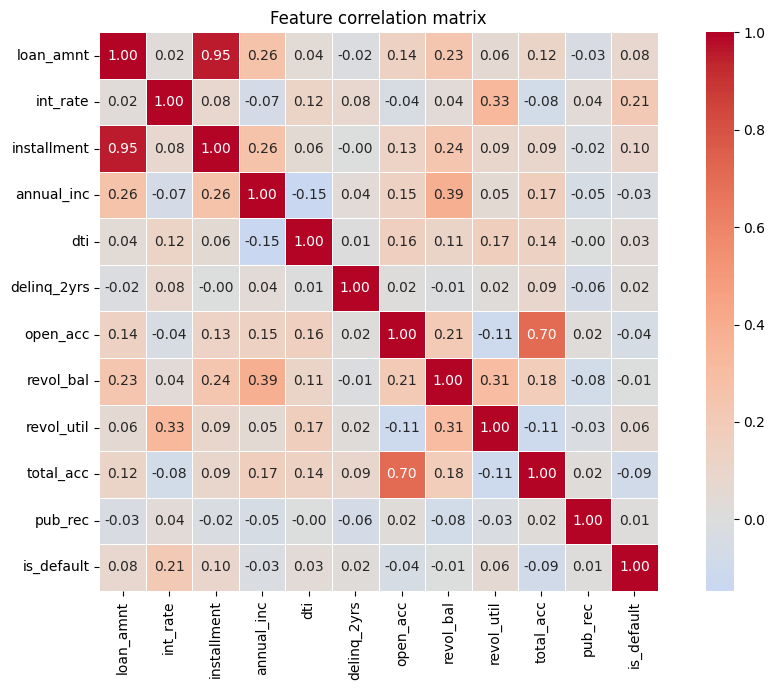

In [18]:
feature_cols = [
    "loan_amnt", "int_rate", "installment", "annual_inc",
    "dti", "delinq_2yrs", "open_acc", "revol_bal",
    "revol_util", "total_acc", "pub_rec", "is_default"
]

corr = df[feature_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot = True, fmt=".2f",cmap="coolwarm", center=0, linewidths=0.5, square=True)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("chart_correlation.png", dpi=150)
plt.show()

Save cleaned databack to SQlit

In [19]:
conn = sqlite3.connect("credit_risk.db")
df.to_sql("loans_clean", conn, index=False, if_exists="replace")
conn.close()

print(f"Saved cleaned table 'loan_clean': {df.shape[0]:,} rows, {df.shape[1]} columns")

Saved cleaned table 'loan_clean': 8,429 rows, 102 columns
